In [1]:
from __future__ import annotations
import timeit
from tensor_builder import NODES, INF, build_adjacency_matrices
from dijkstra_search import dijkstra
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pareto_search import pareto_search, time_matrix, cost_matrix, node_index

In [2]:
def matrix_to_nx(matrix:np.ndarray, node_index: dict[str, int], weight_name: str, nodes: list[str] = NODES) -> nx.Graph:
    index_node = {i: n for n, i in node_index.items()}
    G = nx.DiGraph()
    G.add_nodes_from(nodes)

    n = matrix.shape[0]
    for i in range(n):
        for j in range(n):
            w = matrix[i, j]
            if w == INF or w == 0:
                continue
            G.add_edge(index_node[i], index_node[j], **{weight_name: float(w)})
    return G

time_matrix, cost_matrix, node_index = build_adjacency_matrices()

G_time = matrix_to_nx(time_matrix, node_index, "time")
G_cost = matrix_to_nx(cost_matrix, node_index, "cost")

SOURCE, TARGET= "A", "J"

def compare(label: str, matrix: np.ndarray, G: np.DiGraph, weight_name: str) -> None: 
    my_path, my_total = dijkstra(matrix, SOURCE, TARGET, node_index, NODES)
    nx_path = nx.dijkstra_path(G, SOURCE, TARGET, weight=weight_name)
    nx_total = nx.dijkstra_path_length(G, SOURCE, TARGET, weight=weight_name)

    same_path = my_path == nx_path
    same_total=  np.isclose(my_total, nx_total)

    print(f"\n=== {label.upper()} ===")
    print(f"Original: {my_path} total={my_total}")
    print(f"NetworkX: {nx_path} total={nx_total}")
    print(f"Same Path? {same_path} | Same Total? {same_total}")

    if not same_path and same_total:
        print("different path, identical total: tie, not bug")
    if not same_total:
        print("MISMATCH: totals differ, must investigate")

compare("time", time_matrix, G_time, "time")
compare("cost", cost_matrix, G_cost, "cost")

print("\n=== Runtime Comparison (2000 calls each)")
N = 2000

t_orig_time = timeit.timeit(lambda: dijkstra(time_matrix, SOURCE, TARGET, node_index, NODES), number=N)
t_nx_time = timeit.timeit(lambda: nx.dijkstra_path(G_time, SOURCE, TARGET, weight="time"), number=N)    
t_orig_cost = timeit.timeit(lambda: dijkstra(cost_matrix, SOURCE, TARGET, node_index, NODES), number=N)
t_nx_cost = timeit.timeit(lambda: nx.dijkstra_path(G_cost, SOURCE, TARGET, weight="cost"), number=N)

print(f"[time] Original: {t_orig_time/N*1e6:.2f} us/call")               
print(f"[time] NetworkX: {t_nx_time/N*1e6:.2f} us/call")
print(f"[cost] Original: {t_orig_cost/N*1e6:.2f} us/call")
print(f"[cost] NetworkX: {t_nx_cost/N*1e6:.2f} us/call")


=== TIME ===
Original: ['A', 'B', 'D', 'G', 'J'] total=8.7
NetworkX: ['A', 'B', 'D', 'G', 'J'] total=8.7
Same Path? True | Same Total? True

=== COST ===
Original: ['A', 'B', 'D', 'G', 'J'] total=295.0
NetworkX: ['A', 'B', 'D', 'G', 'J'] total=295.0
Same Path? True | Same Total? True

=== Runtime Comparison (2000 calls each)
[time] Original: 16.45 us/call
[time] NetworkX: 8.03 us/call
[cost] Original: 18.20 us/call
[cost] NetworkX: 8.49 us/call


## Heatmap

In [7]:
def heatmap(result: dict, bins: int=25, save_path: str | None = None) -> None:
    candidates = result["candidates"]
    front = result["pareto_front"]
    src = result["source"]
    dest = result["destination"]

    dominated_routes = {id(pair[0]) for pair in result["dominated_pairs"]}

    all_times = np.array([r.time for r in candidates])
    all_costs = np.array([r.cost for r in candidates])

    dom_times = [r.time for r in candidates if id(r) in dominated_routes]
    dom_costs = [r.cost for r in candidates if id(r) in dominated_routes]
    front_sorted = sorted(front, key=lambda r: r.time)
    front_times = [r.time for r in front_sorted]
    front_costs = [r.cost for r in front_sorted]

    fig, ax = plt.subplots(figsize=(10,6.5))
    
    t_min, t_max = all_times.min(), all_times.max()
    c_min, c_max = all_costs.min(), all_costs.max()

    t_pad = (t_max - t_min) * 0.15 or 1.0
    c_pad = (c_max - c_min) * 0.15 or 1.0

    t_edges = np.linspace(t_min - t_pad, t_max + t_pad, bins)
    c_edges = np.linspace(c_min - c_pad, c_max + c_pad, bins)
    T, C = np.meshgrid(t_edges, c_edges)

    T_norm = (T - T.min())/(T.max() - T.min())
    C_norm = (C - C.min())/(C.max() - C.min())
    combined = T_norm + C_norm

    mesh = ax.pcolormesh(
        T, C, combined, 
        cmap = "RdYlGn_r",
        alpha = 0.35,
        shading ="auto",
        zorder=1
    )
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Combined time+cost band (lower = better)", fontsize=9)

    if len(front_sorted) >=2:
        ax.plot(
            front_times, front_costs, 
            color="black", linewidth=1.5, linestyle="--", zorder = 4, alpha = 0.8)
        for i in range(len(front_sorted) - 1):
            r_a, r_b = front_sorted[i], front_sorted[i + 1]
            d_time = r_b.time - r_a.time
            d_cost = r_a.cost - r_b.cost
            rate = d_cost/d_time if d_time != 0 else float("inf")

            mid_time = (r_a.time + r_b.time) / 2
            mid_cost = (r_a.cost + r_b.cost) / 2
            ax.annotate(
                f"${rate:,.2f}/ hour saved",
                xy=(mid_time, mid_cost),
                xytext=(0,-18),
                textcoords="offset points",
                fontsize=9.5,
                fontweight="bold",
                color="black",
                ha="center",
                zorder=7,
                bbox=dict(boxstyle="round, pad=0.25", fc="white", ec="black", alpha=0.85))
    ax.scatter(
        dom_times, dom_costs, color="dimgrey", s=80, zorder=3,
        label=f"Dominated Routes ({len(dom_times)})",
        edgecolors="black", linewidths=0.5
    )

    ax.scatter(
        front_times, front_costs, color="crimson", s=280, zorder=5,
        label=f"Pareto-Optimal route {'s' if len(front_sorted) != 1 else ''}({len(front_sorted)})",
        marker = "*", edgecolors="black", linewidths=1.3)

    for r in front_sorted:
        ax.annotate(
            r.path_str, xy=(r.time, r.cost),
            xytext=(12, 12),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            color="black", 
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            zorder = 6)

    ax.set_xlabel("Total Time", fontsize=12)
    ax.set_ylabel("Total Cost", fontsize=12)
    ax.set_title(f"Objective Space: {src} -> {dest}\n"
                 f"Pareto Front({len(front_sorted)} non-dominated route)"
                 f"{'s' if len(front_sorted) !=1 else ''} out of {len(candidates)} candidates",
                 fontsize=13, pad=20)

    ax.legend(fontsize=10, loc="best")
    ax.grid(True, linestyle="--", alpha=0.3, color="white", zorder=2)
    if len(front_sorted) >=2:
        fastest = front_sorted[0]
        cheapest = front_sorted[1]
        d_time = cheapest.time - fastest.time
        d_cost = fastest.cost - cheapest.cost
        rate = d_cost/d_time if d_time != 0 else float("inf")

        fig.text(
            0.5, 1.18, 
            f"${rate:.2f} saved per hour of extra travel time",
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=19, fontweight="bold", color="black")

        fig.text(
            0.5, -0.15,
            f"Fastest = {fastest.path_str}, Cheapest = {cheapest.path_str}"
            f"+{d_time:.1f}h, -${d_cost:.2f}",
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=10.5, style="italic", color="black")
    plt.tight_layout(rect=[0, 0.08, 1, 0.9])

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches = "tight")
    plt.show()

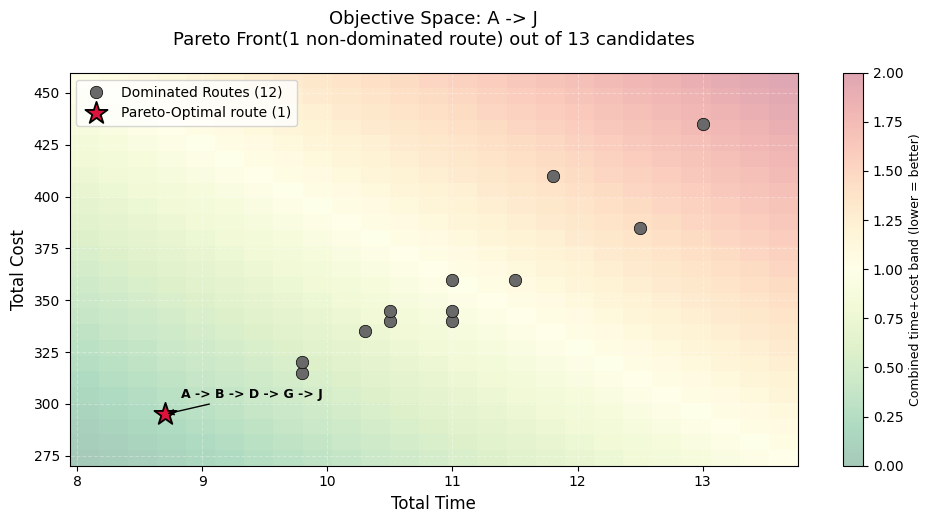

In [8]:
heatmap(pareto_search(time_matrix, cost_matrix, "A", "J", node_index)
)